In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
cols=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

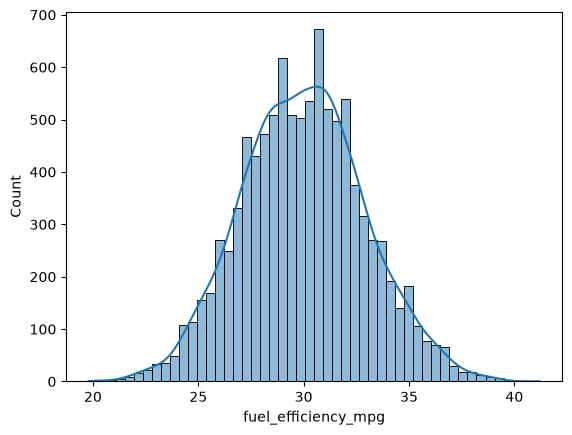

In [4]:
sns.histplot(df.fuel_efficiency_mpg, bins=50, kde=True) #it doesn't have a long tail

Question 1
There's one column with missing values. What is it?

- 'engine_displacement'
- 'horsepower'
- 'vehicle_weight'
- 'model_year'

In [5]:
df[cols].isnull().sum() #horsepower is the column that have missing values

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Question 2
What's the median (50% percentile) for variable 'horsepower'?

204
254
304
354

In [6]:
df.horsepower.median() # 254 is the median of the horsepower col

np.float64(254.0)

data set preparation and spliting

In [7]:
df = df[cols]
df.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [8]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[cols]
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val-n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]


df_train2 = df_train.copy()
df_val2 = df_val.copy()
df_test2 = df_test.copy()

Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [9]:
print(df_train2.horsepower.isnull().sum())
df_train.horsepower = df_train.horsepower.fillna(0)
df_val.horsepower = df_val.horsepower.fillna(0)
df_test.horsepower = df_test.horsepower.fillna(0)


hp_mean = df_train2.horsepower.mean()
print(df_train2.horsepower.isnull().sum())
df_train2.horsepower = df_train2.horsepower.fillna(hp_mean)
df_val2.horsepower = df_val2.horsepower.fillna(hp_mean)
df_test2.horsepower = df_test2.horsepower.fillna(hp_mean)
print(df_train2.horsepower.isnull().sum())
y_train = df_train.fuel_efficiency_mpg
y_train2 = df_train2.fuel_efficiency_mpg
del df_train['fuel_efficiency_mpg']
del df_train2['fuel_efficiency_mpg']


538
538
0


In [10]:
print(df_train.horsepower.mean())

print(df_train2.horsepower.mean())

231.6465
254.46338337605272


In [11]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

In [12]:
y_val = df_val['fuel_efficiency_mpg']
y_val2 = df_val2['fuel_efficiency_mpg']

del df_val['fuel_efficiency_mpg']
del df_val2['fuel_efficiency_mpg']

In [13]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    W = XTX_inv.dot(X.T).dot(y)
    return W[0], W[1:]

In [14]:
w0_1, W_1 = train_linear_regression(df_train, y_train)

w0_2, W_2 = train_linear_regression(df_train2, y_train2)

In [15]:
y_pred_val = w0_1 + df_val.values.dot(W_1)

y_pred_val2 = w0_2 + df_val2.values.dot(W_2)

In [16]:
def rmse(y, y_pred):
    mean_error = np.mean((y-y_pred)**2)
    return np.sqrt(mean_error)

In [17]:
print(round(rmse(y_val, y_pred_val), 3))

print(round(rmse(y_val2, y_pred_val2),3))

#answer: with mean

2.205
2.202


Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?
- If multiple options give the same best RMSE, select the smallest r.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [ ]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[cols]

df = df.fillna(0)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

def train_linear_regression_regularized(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX_inv_reg = np.linalg.inv(XTX+ r*np.eye(XTX.shape[0])) 
    W = XTX_inv_reg.dot(X.T).dot(y)
    return W[0], W[1:]

r_arr = [0, 0.01, 0.1, 1, 5, 10, 100]

scores ={}
for i in r_arr:
    w0, w=train_linear_regression_regularized(df_train, y_train, r =i)
    y_pred = w0 + df_val.values.dot(w)
    scores[i] = (round(rmse(y_val, y_pred),4))

print(scores)

#Answer 0.01

{0: np.float64(2.207), 0.01: np.float64(2.2067), 0.1: np.float64(2.2195), 1: np.float64(2.3364), 5: np.float64(2.3952), 10: np.float64(2.4051), 100: np.float64(2.4146)}
2.2067


Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036


**Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.**

In [31]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[cols]

n_test = int(n*0.2)
n_val = int(n*0.2)
n_train = n-n_test - n_val

df.horsepower = df.horsepower.fillna(0)

scores = {}

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    w0, w = train_linear_regression(df_train, y_train)
    y_pred = w0 + df_val.values.dot(w)

    scores[s] = rmse(y_val, y_pred)

print(scores)
round(np.std(list(scores.values())),3) #answer 0.029

print(min(scores, key = scores.get), min(scores.values()))


{0: np.float64(2.239204143046126), 1: np.float64(2.2021128210838845), 2: np.float64(2.1634197787530947), 3: np.float64(2.2043588768539224), 4: np.float64(2.2018800943311554), 5: np.float64(2.2457851509085134), 6: np.float64(2.2697212079524043), 7: np.float64(2.190794599933443), 8: np.float64(2.216611201686444), 9: np.float64(2.2070365928178957)}
2 2.1634197787530947


Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [ ]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[cols]

df = df.fillna(0)

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train_val = pd.concat([df_train,df_val], ignore_index = True)

y_train_val = df_train_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_train_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

w0, w = train_linear_regression_regularized(df_train_val, y_train_val, r=0.001)

y_pred = w0+df_test.values.dot(w)

print(round(rmse(y_test, y_pred),3)) # Answer b. 2.236


2.236
